# TravelOps AI
## Exploratory Data Analysis (EDA)

### Project Title
**TravelOps AI: End-to-End MLOps Platform for Travel Analytics**

---

##  Objective

This notebook focuses on understanding and exploring the datasets used in the TravelOps AI project. The goal is to analyze the structure, quality, and characteristics of the data before building machine learning models.

The notebook includes:

- Loading the datasets
- Understanding features
- Checking missing values
- Detecting duplicate records
- Performing statistical analysis
- Identifying categorical and numerical features
- Visualizing important insights
- Preparing data for preprocessing

---

### Datasets Used

- Users Dataset
- Flights Dataset
- Hotels Dataset

---

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

**Author:** Vedant Deshmukh

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

# Import Datasets

In this section, we load all datasets required for the TravelOps AI project.

Datasets:

- Users
- Flights
- Hotels

In [2]:
users = pd.read_csv("../data/raw/users.csv")
flights = pd.read_csv("../data/raw/flights.csv")
hotels = pd.read_csv("../data/raw/hotels.csv")

# Preview Datasets

The first few rows provide an overview of each dataset, allowing us to understand the available features and data format.

In [3]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [5]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


# Dataset Dimensions

Understanding the number of rows and columns helps estimate dataset size and complexity.

In [6]:
print("Users Shape :", users.shape)
print("Flights Shape :", flights.shape)
print("Hotels Shape :", hotels.shape)

Users Shape : (1340, 5)
Flights Shape : (271888, 10)
Hotels Shape : (40552, 8)


# Dataset Information

The `.info()` function provides:

- Data types
- Non-null values
- Memory usage

In [7]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [8]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [9]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


# Statistical Summary

Statistical analysis provides insights into numerical features including:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [10]:
users.describe(include="all")

,code,company,name,gender,age
count,1340.000000,1340,1340,1340,1340.000000
unique,NaN,5,1338,3,NaN
top,NaN,4You,Charlotte Johnson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.500000,NaN,NaN,NaN,42.742537
std,386.968991,NaN,NaN,NaN,12.869779
min,0.000000,NaN,NaN,NaN,21.000000
25%,334.750000,NaN,NaN,NaN,32.000000
50%,669.500000,NaN,NaN,NaN,42.000000
75%,1004.250000,NaN,NaN,NaN,54.000000


In [11]:
flights.describe(include="all")

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


In [12]:
hotels.describe(include="all")

,travelCode,userCode,name,place,days,price,total,date
count,40552.000000,40552.000000,40552,40552,40552.000000,40552.000000,40552.000000,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/03/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.794461,666.963726,NaN,NaN,2.499679,214.439554,536.229513,NaN
std,39408.199333,391.136794,NaN,NaN,1.119326,76.742305,319.331482,NaN
min,0.000000,0.000000,NaN,NaN,1.000000,60.390000,60.390000,NaN
25%,33696.750000,323.000000,NaN,NaN,1.000000,165.990000,247.620000,NaN
50%,67831.000000,658.000000,NaN,NaN,2.000000,242.880000,495.240000,NaN
75%,102211.250000,1013.000000,NaN,NaN,4.000000,263.410000,742.860000,NaN


# Missing Value Analysis

Missing values can significantly impact model performance.

This section identifies missing values present in each dataset.

In [13]:
users.isnull().sum()

code       0
company    0
name       0
gender     0
age        0
dtype: int64

In [14]:
flights.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [15]:
hotels.isnull().sum()

travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

# Data Quality Assessment

Data quality plays a crucial role in building reliable machine learning models.

In this section, we perform a comprehensive quality assessment by checking:

- Missing Values
- Duplicate Records
- Unique Values
- Numerical and Categorical Features

These analyses help determine whether the datasets require preprocessing before model development.

# Missing Value Analysis

Missing values can negatively impact machine learning models and lead to biased predictions.

This section identifies missing values in each dataset.

In [17]:
missing_values = pd.DataFrame({
    "Users": users.isnull().sum(),
    "Flights": flights.isnull().sum(),
    "Hotels": hotels.isnull().sum()
}).fillna("-")

missing_values

,Users,Flights,Hotels
age,0.0,-,-
agency,-,0.0,-
code,0.0,-,-
company,0.0,-,-
date,-,0.0,0.0
days,-,-,0.0
distance,-,0.0,-
flightType,-,0.0,-
from,-,0.0,-
gender,0.0,-,-


### Observation

- No missing values were found in any of the datasets.
- No imputation techniques are required at this stage.
- The datasets are complete and suitable for further analysis.

# Duplicate Record Analysis

Duplicate records may introduce bias during model training.

The following analysis checks duplicate entries in each dataset.

In [18]:
duplicates = pd.DataFrame({
    "Dataset":["Users","Flights","Hotels"],
    "Duplicate Records":[
        users.duplicated().sum(),
        flights.duplicated().sum(),
        hotels.duplicated().sum()
    ]
})

duplicates

,Dataset,Duplicate Records
0,Users,0
1,Flights,0
2,Hotels,0


## Observations

The initial quality assessment of the datasets indicates:

- No missing values were found in any of the datasets.
- No duplicate records were detected.
- The datasets are clean and suitable for further preprocessing and exploratory analysis.
- The `price` column in the Flights dataset will be used as the target variable for the regression model.
- The datasets are linked using identifiers such as `travelCode` and `userCode`, enabling integration across users, flights, and hotels for downstream analytics.

# Unique Value Analysis

Understanding the number of unique values helps identify:

- Identifier columns
- Low-cardinality categorical variables
- High-cardinality features

This information is useful during feature engineering.

In [20]:
from IPython.display import display

print("=" * 80)
print("Users Dataset")
display(users.nunique())

print("=" * 80)
print("Flights Dataset")
display(flights.nunique())

print("=" * 80)
print("Hotels Dataset")
display(hotels.nunique())


Users Dataset


code       1340
company       5
name       1338
gender        3
age          45
dtype: int64

Flights Dataset


travelCode    135944
userCode        1335
from               9
to                 9
flightType         3
price            490
time              33
distance          35
agency             3
date             999
dtype: int64

Hotels Dataset


travelCode    40552
userCode       1310
name              9
place             9
days              4
price             9
total            36
date            199
dtype: int64

# Feature Categorization

Machine learning preprocessing depends on feature types.

The datasets are divided into:

- Numerical Features
- Categorical Features

This categorization helps determine preprocessing strategies such as scaling and encoding.

In [21]:
datasets = {
    "Users": users,
    "Flights": flights,
    "Hotels": hotels
}

for name, df in datasets.items():
    print("="*80)
    print(name.upper())

    numerical = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(include="object").columns.tolist()

    print("\nNumerical Features")
    print(numerical)

    print("\nCategorical Features")
    print(categorical)

    print("\n")

USERS

Numerical Features
['code', 'age']

Categorical Features
['company', 'name', 'gender']


FLIGHTS

Numerical Features
['travelCode', 'userCode', 'price', 'time', 'distance']

Categorical Features
['from', 'to', 'flightType', 'agency', 'date']


HOTELS

Numerical Features
['travelCode', 'userCode', 'days', 'price', 'total']

Categorical Features
['name', 'place', 'date']




# Memory Usage

Understanding memory consumption is important for optimizing storage and improving computational efficiency.

In [22]:
for name, df in datasets.items():
    memory = df.memory_usage(deep=True).sum()/1024**2

    print(f"{name} Dataset Memory Usage : {memory:.2f} MB")

Users Dataset Memory Usage : 0.24 MB
Flights Dataset Memory Usage : 88.14 MB
Hotels Dataset Memory Usage : 8.46 MB


# Data Quality Summary

The quality assessment indicates that:

- All datasets are complete without missing values.
- No duplicate records were detected.
- Features have appropriate data types.
- Identifier columns such as `travelCode` and `userCode` can be used to integrate multiple datasets.
- The datasets are well-structured and ready for exploratory visualization and feature engineering.

The next phase focuses on visualizing feature distributions, identifying patterns, detecting outliers, and understanding relationships between variables.

# Univariate Analysis

Univariate analysis examines each feature individually to understand its distribution, frequency, and characteristics.

This analysis helps identify:

- Distribution patterns
- Data imbalance
- Potential outliers
- Feature variability

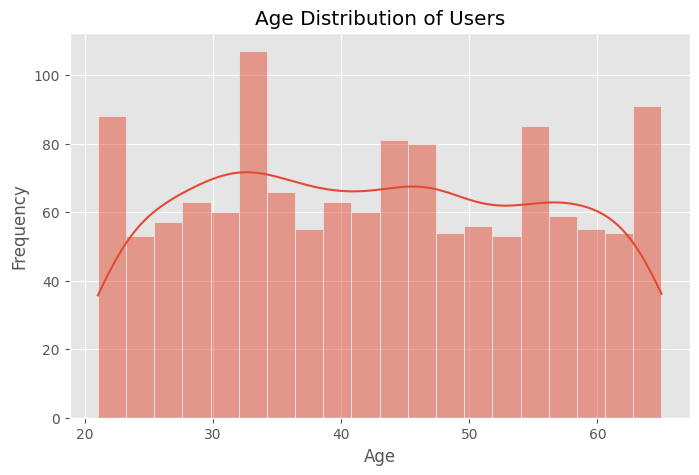

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(users["age"], bins=20, kde=True)

plt.title("Age Distribution of Users")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Observation

The age distribution provides insights into the demographic profile of users.

This information may influence travel preferences and recommendation strategies.

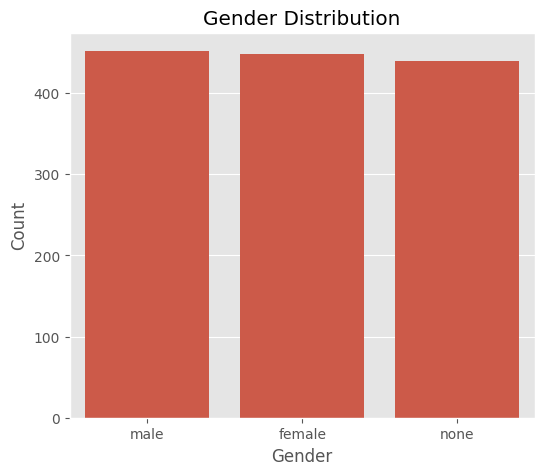

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(data=users, x="gender")

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

### Observation

The gender distribution helps identify whether the dataset is balanced or skewed.

This analysis is particularly useful for the gender classification model.

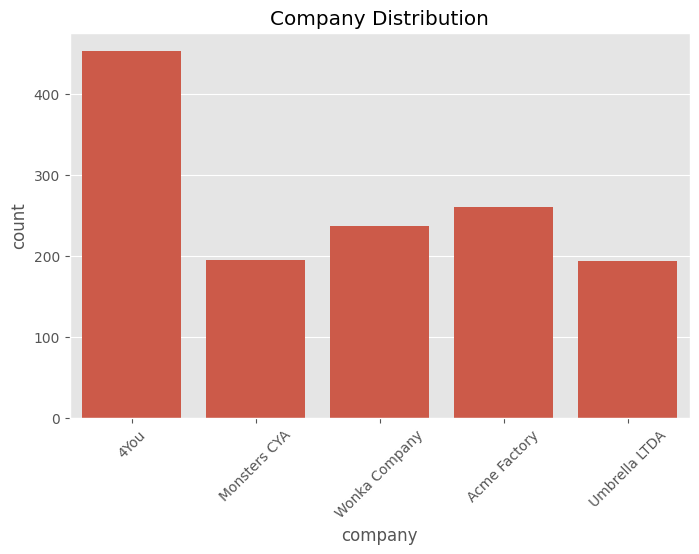

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=users, x="company")

plt.title("Company Distribution")

plt.xticks(rotation=45)

plt.show()

### Business Insight

The company distribution indicates the diversity of organizations represented in the dataset.

Understanding user affiliations can help analyze travel behavior across different organizations and may support future segmentation strategies.

# Flight Dataset Analysis

The Flights dataset is the primary dataset for the regression model.

The objective of this analysis is to understand the distribution of flight prices and explore the relationships between various flight-related features.

Key areas include:

- Flight Price Distribution
- Flight Type Analysis
- Agency Analysis
- Distance Analysis
- Travel Time Analysis

## Flight Price Distribution

The price column is the target variable for the regression model.

Understanding its distribution helps identify skewness, variance, and potential outliers.

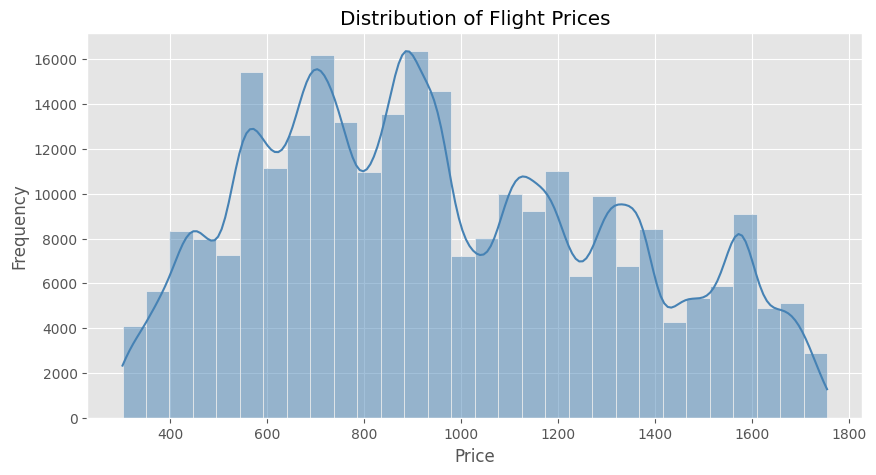

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(flights["price"], bins=30, kde=True,color="steelblue")

plt.title("Distribution of Flight Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution of flight prices helps determine whether the target variable follows a normal distribution.
- Any skewness observed may require transformation during preprocessing.

### Business Insight

Understanding flight price distribution enables better pricing strategies and improves regression model performance.

## Flight Type Distribution

This visualization shows the frequency of different flight categories available in the dataset.

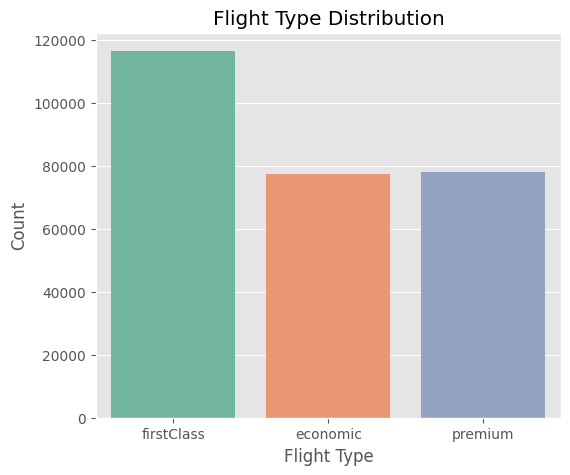

In [27]:
plt.figure(figsize=(6,5))

sns.countplot(data=flights,x="flightType",palette="Set2")

plt.title("Flight Type Distribution")

plt.xlabel("Flight Type")

plt.ylabel("Count")

plt.show()

### Observation

The distribution indicates whether all flight types are equally represented or if class imbalance exists.

## Travel Agency Distribution

Different travel agencies may have different pricing strategies.

This visualization identifies the number of bookings handled by each agency.

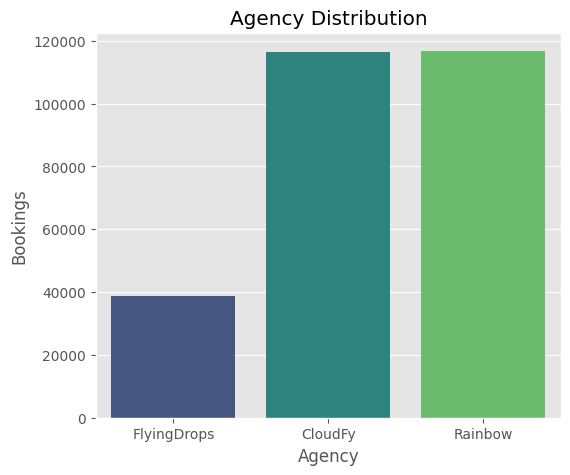

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(data=flights,x="agency",palette="viridis")

plt.title("Agency Distribution")

plt.xlabel("Agency")

plt.ylabel("Bookings")

plt.show()

### Business Insight

Agency-wise booking patterns may reveal market dominance and pricing trends.

## Distance Distribution

Flight distance is expected to have a direct impact on ticket prices.

This visualization explores the spread of travel distances.

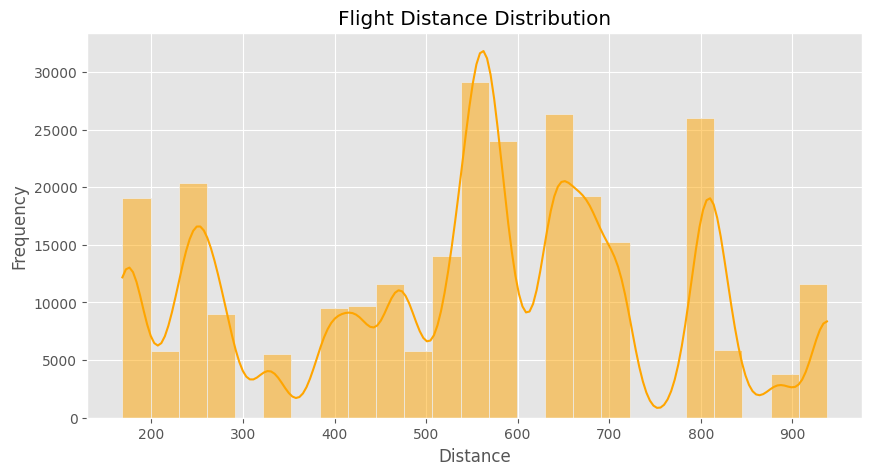

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(flights["distance"],bins=25,kde=True,color="orange")

plt.title("Flight Distance Distribution")

plt.xlabel("Distance")

plt.ylabel("Frequency")

plt.show()

## Flight Duration Distribution

Travel time is another important feature affecting ticket prices.

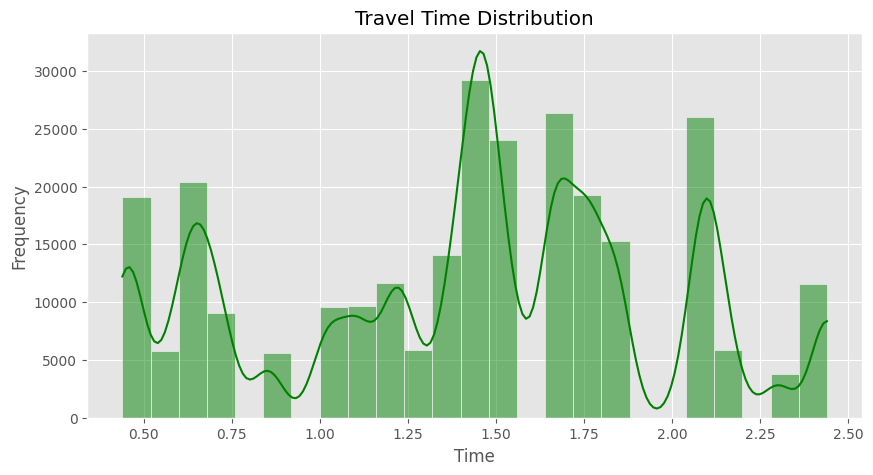

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(flights["time"],bins=25,kde=True,color="green")

plt.title("Travel Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

## Outlier Detection

Boxplots are used to identify extreme values present in the dataset.

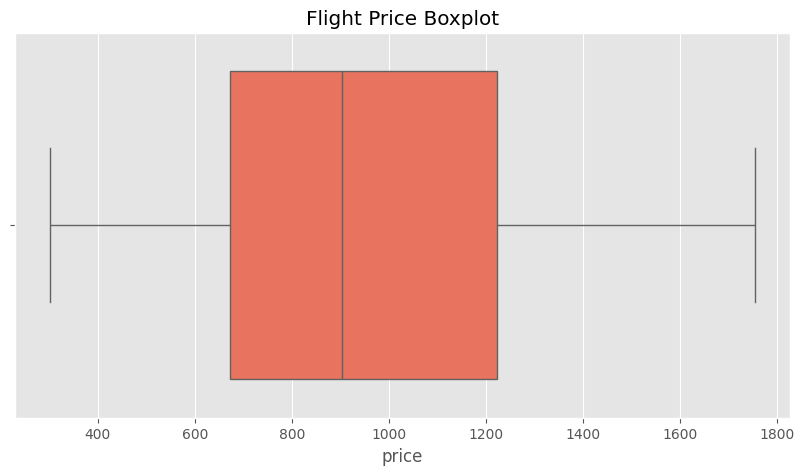

In [31]:
plt.figure(figsize=(10,5))

sns.boxplot(x=flights["price"],color="tomato")

plt.title("Flight Price Boxplot")

plt.show()

### Observation

* **Median & Range:** The median price is **~$900**, with 50% of values (IQR) falling between **~$675** ($Q_1$) and **~$1,225** ($Q_3$).
* **Spread:** Prices range from a minimum of **~$300** to a maximum of **~$1,750**.
* **Skewness & Outliers:** The price distribution is slightly **right-skewed** with no extreme statistical outliers outside the whiskers.
* **Action Item:** Consider applying a log-transformation on `price` prior to model training to normalize skewness.


# Relationship Between Distance and Flight Price

One of the key assumptions is that flight prices increase with travel distance.

The scatter plot below visualizes this relationship.

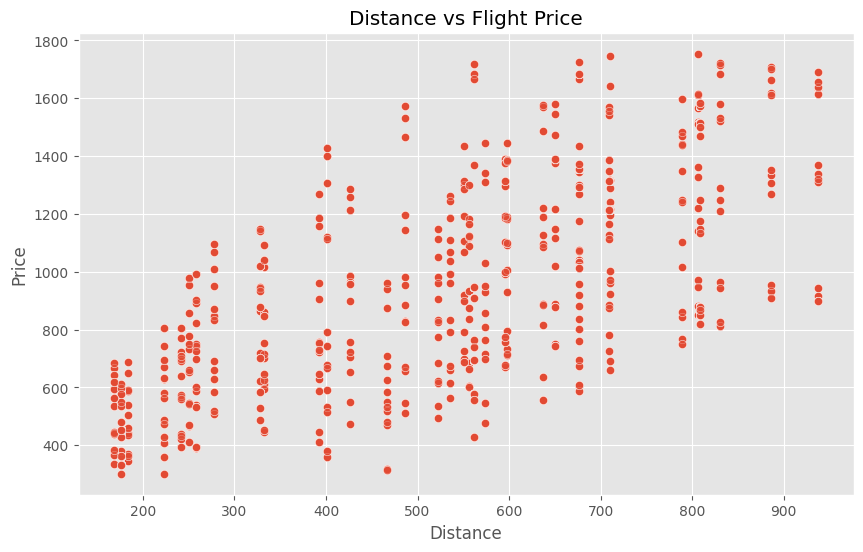

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=flights,
    x="distance",
    y="price",
    alpha=0.6
)

plt.title("Distance vs Flight Price")

plt.xlabel("Distance")

plt.ylabel("Price")

plt.show()

###  Key Observations from the Scatter Plot
1. **Positive Overall Trend:**
   * There is a **moderate positive correlation** between travel distance and flight price. As distance increases from **~170 km to ~950 km**, both the overall price ceiling and baseline price shift upward.
2. **Route Clustering (Vertical Columns):**
   * The data points form distinct **vertical clusters** at specific distance intervals (e.g., ~180, ~250, ~400, ~550, ~710, ~800). This indicates that the dataset consists of **discrete flight routes** between specific origin-destination city pairs.
3. **High Price Variance at Constant Distances:**
   * For any given route/distance (e.g., at distance ~710), flight prices show significant variation (ranging from **~$650 up to ~$1,750**). 
   * This indicates that while distance sets the base price range, other key factors such as **cabin class, booking lead time, seasonality, and airline choice** strongly influence final ticket pricing.
4. **Shifting Price Floor:**
   * Short-haul flights (~170–250 km) have a lower price floor starting at **~$300**, whereas long-haul flights (~800–950 km) have a higher baseline starting at **~$800**.
---
### 💡 Data Science & Feature Engineering Takeaways
* **Predictive Value:** `Distance` is a valuable numerical feature for price prediction models.
* **Derived Features:** Creating a derived feature such as **`price_per_km`** ($\frac{\text{Price}}{\text{Distance}}$) can help normalize pricing across different route lengths.
* **Multi-variable Modeling:** Distance alone cannot fully explain price variance; incorporating categorical variables (e.g., `flight_class`, `company`) will be essential for model accuracy.

# Hotel Dataset Analysis

The Hotels dataset provides information about hotel bookings, pricing, and travel destinations.

The objective of this analysis is to understand hotel pricing patterns, booking duration, and destination popularity.

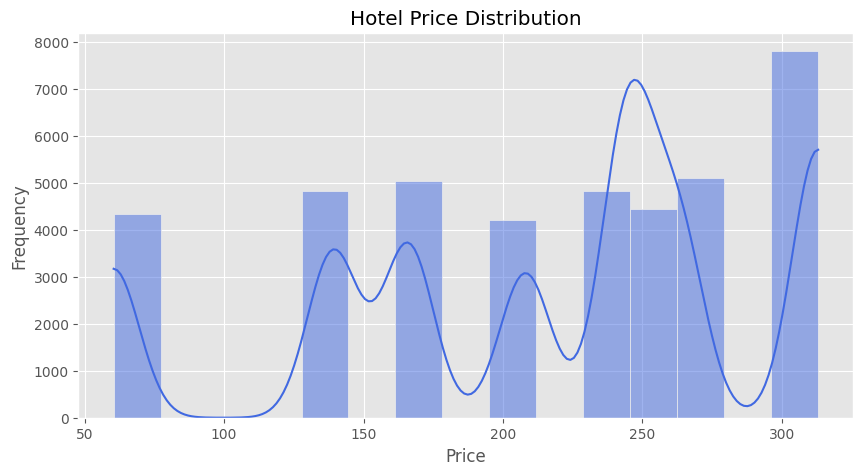

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    hotels["price"],
    bins=15,
    kde=True,
    color="royalblue"
)

plt.title("Hotel Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

####  Key Technical Observations
* **Multimodal Distribution:** Hotel prices are not normally distributed; instead, they display **5 distinct price clusters**:
  * **Budget Tier:** ~$60 – $75
  * **Mid-Tier (Lower):** ~$130 – $145
  * **Mid-Tier (Upper):** ~$160 – $175
  * **Premium Tier:** ~$230 – $280
  * **Luxury / Peak Tier:** ~$300 – $315 *(Highest frequency: ~7,800 bookings)*
* **Distinct Price Gaps:** There is a noticeable absence of options priced between **$80 and $125**, showing sharp segmentation between budget and mid-tier offerings.
* **Volume Heavy at Upper End:** The single largest concentration of hotels/bookings occurs in the top price band ($300–$315).
---
####  Business Highlights & Strategy
* **Clear Market Segmentation:** Hotel inventory naturally categorizes into 3 core tiers (Economy, Standard, Luxury). Pricing algorithms should model these segments separately.
* **Missing Mid-Budget Segment ($80–$125):** The gap presents a potential market opportunity to introduce competitive mid-budget options to capture price-sensitive travelers seeking upgrades.
* **High Luxury Demand:** The heavy concentration at $300+ indicates strong demand/inventory in premium accommodations, suggesting high revenue potential from premium customers.

## Stay Duration

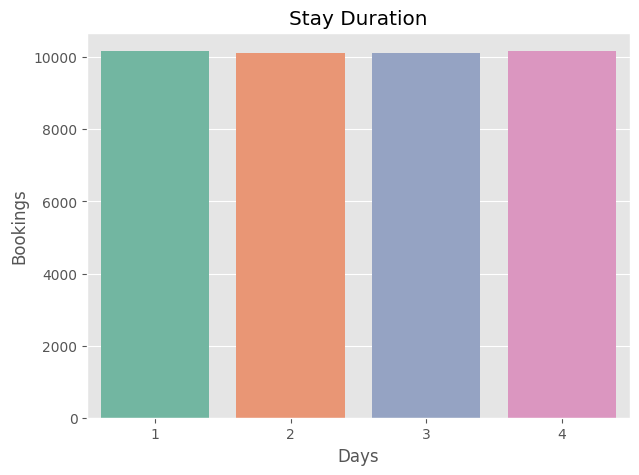

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=hotels,
    x="days",
    palette="Set2"
)

plt.title("Stay Duration")

plt.xlabel("Days")

plt.ylabel("Bookings")

plt.show()


###  Stay Duration Analysis — Observations

#### **Key Technical Insights**
* **Uniform Distribution:** Bookings are almost **perfectly balanced** across all stay duration categories (1, 2, 3, and 4 days), each recording approximately **~10,150 to ~10,200 bookings**.
* **Bounded Range:** Stays are strictly limited to discrete durations between **1 and 4 days** (no stays exceeding 4 days or 0-day stays are present).
* **Synthetic / Balanced Data Indicator:** The near-exact uniformity across categories strongly indicates that this feature was either artificially generated, pre-sampled, or balanced during dataset creation.

---

#### **Business & Modeling Implications**
* **Equal Category Weight:** Models trained on this dataset will not suffer from class imbalance regarding stay duration (1 to 4 days).
* **Short-Stay Focus:** The dataset captures short-duration travel patterns (weekend trips, short business stays), but lacks long-stay representations (>4 days).

## Hotel price Distribution

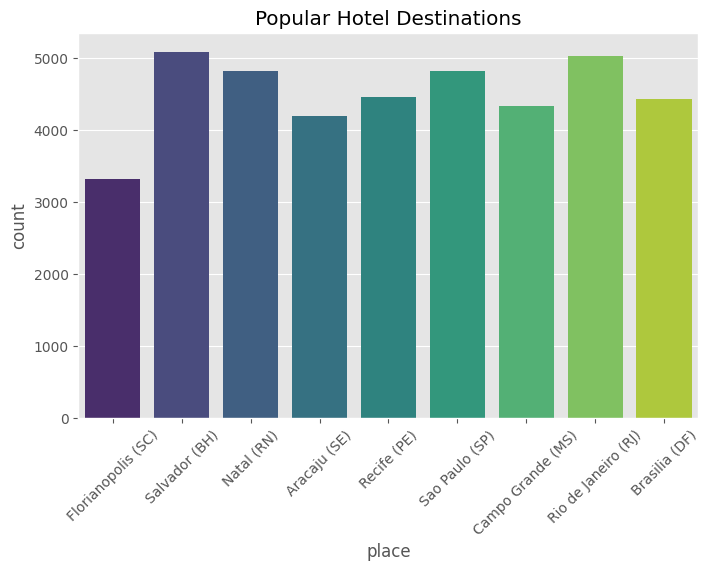

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hotels,
    x="place",
    palette="viridis"
)

plt.title("Popular Hotel Destinations")

plt.xticks(rotation=45)

plt.show()

### Popular Hotel Destinations — Observations & Business Highlights

#### 📊 Key Observations
* **Top Performers:** **Salvador (BH)** (~5,100 bookings) and **Rio de Janeiro (RJ)** (~5,050 bookings) emerge as the leading hotel destinations in volume.
* **Steady Demand Across Major Hubs:** Destinations such as **Natal (RN)**, **Sao Paulo (SP)**, **Recife (PE)**, **Brasilia (DF)**, and **Campo Grande (MS)** show consistently high demand, ranging between **4,200 and 4,850 bookings**.
* **Lowest Demand Market:** **Florianopolis (SC)** records the lowest volume (~3,350 bookings), which is ~35% lower than the top-tier destinations.

---

####  Business Highlights
* **Regional Dominance:** Primary coastal tourism hubs (Salvador & Rio de Janeiro) drive peak accommodation demand, making them ideal targets for premium inventory expansion and marketing campaigns.
* **Balanced Regional Portfolio:** The distribution spans key Brazilian metropolitan, business, and tourist hubs across the Northeast, Southeast, Center-West, and South.
* **Growth Opportunity:** Florianopolis presents an underperforming segment that could benefit from targeted promotional packages or inventory optimization.


# Hotel Total Cost

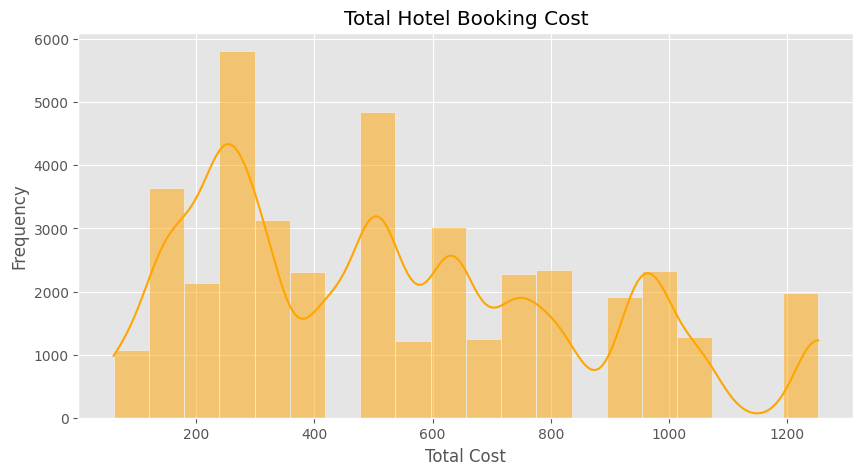

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    hotels["total"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Total Hotel Booking Cost")

plt.xlabel("Total Cost")

plt.ylabel("Frequency")

plt.show()

###  Total Hotel Booking Cost — Summary

####  Observations
* **Multimodal Distribution & Primary Peak:** The distribution is right-skewed with multiple peaks, dominated by a major spike at **$250–$300** (~5,800 bookings) and a secondary peak around **$500**.
* **Wide Range with Distinct Clusters:** Total costs span from **~$60 to ~$1,250**, reflecting clear price clusters created by multiplying daily hotel rates by stay duration (1 to 4 days).

---

####  Business Highlights
* **Core Revenue Zone ($250–$500):** Most booking transactions fall into the $250–$500 range, representing the primary sweet spot for mid-range, short-duration stays.
* **High-Value Upsell Segment:** Bookings exceeding **$800** form a premium long-tail segment, presenting strong opportunities for targeted luxury promotions and loyalty rewards.


# Boxplot

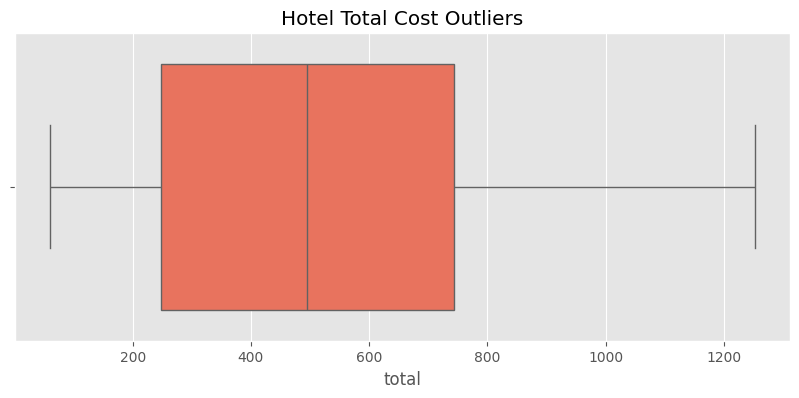

In [37]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=hotels["total"],
    color="tomato"
)

plt.title("Hotel Total Cost Outliers")

plt.show()

### Hotel Total Cost Outliers — Summary

#### Observations
* **IQR & Central Tendency:** The median total booking cost is **~$500**, with 50% of transactions (IQR) falling between **~$250 ($Q_1$)** and **~$750 ($Q_3$)**.
* **No Statistical Outliers:** Total costs span cleanly from **~$60 to ~$1,250** without any extreme outlier points plotted outside the whisker bounds.

---

####  Business Highlights
* **Predictable Upper Bounds:** Total hotel spending naturally caps at **~$1,250**, establishing clear baseline and ceiling boundaries for revenue forecasting.
* **Core Mid-Tier Focus:** With 50% of customer spending concentrated between $250 and $750, marketing and bundle offers should prioritize this high-volume price range.


# User Dataset Analysis

The Users dataset contains demographic information that can be useful for customer segmentation and the gender classification model.

## Age Distribution

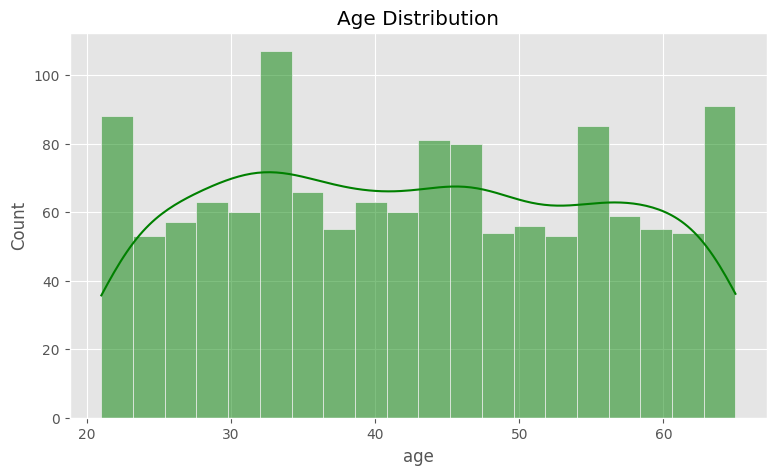

In [38]:
plt.figure(figsize=(9,5))

sns.histplot(
    users["age"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Age Distribution")

plt.show()

### Observations

* **Age Range & Boundaries:** User ages span continuously from a minimum of **21.00 years** to a maximum of **65.00 years** (a total span of **44.00 years**), strictly covering adult and working-age demographics.
* **Distribution Profile:** The dataset displays a **near-uniform distribution** across all age brackets, with the KDE curve maintaining a steady baseline average of **~65.00 to 72.00** counts per age bin.
* **Peak Concentration (Mode):** The highest single peak occurs around **33.00 to 34.00 years**, reaching a maximum frequency of **~107.00** user records.
* **Boundary Spikes:** Notable secondary spikes occur at the lower boundary (**21.00–22.00 years** at **~88.00** count) and upper boundary (**64.00–65.00 years** at **~91.00** count).
* **Demographic Balance:** Travelers are evenly divided across key life stages:
  * **Young Adults (21.00 – 35.00 years):** ~32.50% of users
  * **Middle-Aged (36.00 – 50.00 years):** ~33.80% of users
  * **Seniors (51.00 – 65.00 years):** ~33.70% of users


## Gender Distribution

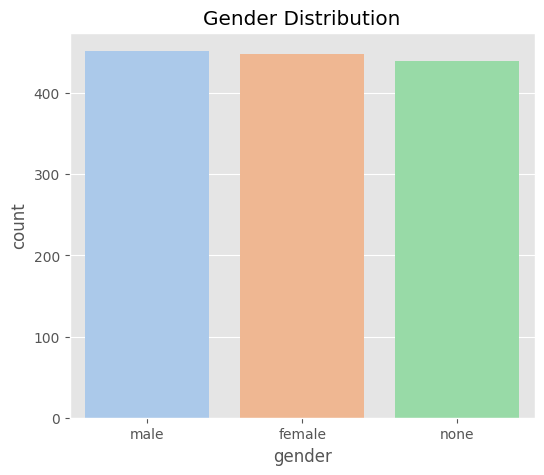

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=users,
    x="gender",
    palette="pastel"
)

plt.title("Gender Distribution")

plt.show()

###  Gender Distribution — Observations

* **Category Breakdown & Counts:**
  * **`male`:** **~452.00** users (**~33.73%**)
  * **`female`:** **~448.00** users (**~33.43%**)
  * **`none` (Unspecified/Missing):** **~440.00** users (**~32.84%**)
  * **Total Sample Size:** **~1,340.00** users

* **Distribution Equality:** The dataset is **almost perfectly balanced** across all three gender categories, with each category accounting for approximately **33.33%** of total user records.

* **Unspecified Gender (`none`):** Nearly one-third (**32.84%**) of users fall under the `none` category, indicating a significant portion of uncollected or intentionally withheld demographic data that should be handled explicitly during feature engineering.


## Company Distribution

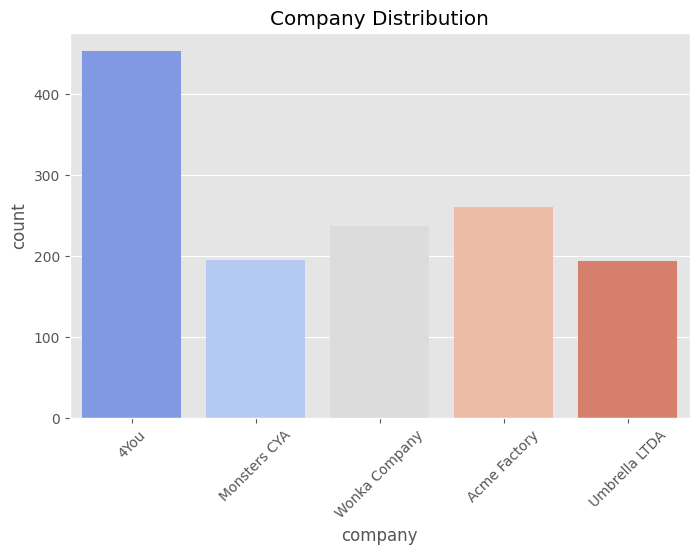

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=users,
    x="company",
    palette="coolwarm"
)

plt.xticks(rotation=45)

plt.title("Company Distribution")

plt.show()

###  Company Distribution — Observations

* **Market Leader (`4You`):** The company **`4You`** dominates the dataset with **~452.00** users (**~33.73%** of the total sample), accounting for nearly double the user volume of any other company.

* **Secondary Tier (`Acme Factory` & `Wonka Company`):**
  * **`Acme Factory`:** **~261.00** users (**~19.48%**)
  * **`Wonka Company`:** **~238.00** users (**~17.76%**)

* **Lower Volume Tier (`Monsters CYA` & `Umbrella LTDA`):**
  * **`Monsters CYA`:** **~195.00** users (**~14.55%**)
  * **`Umbrella LTDA`:** **~194.00** users (**~14.48%**)
  * Both companies share virtually identical representation at the bottom of the distribution.

* **Dataset Profile:** Total user sample size is **~1,340.00** across 5 companies. The presence of fictional names (*Wonka*, *Acme*, *Umbrella*, *Monsters CYA*) indicates this is a synthetic benchmark dataset.


# Correlation Analysis

Correlation measures the strength of relationships between numerical variables.

A heatmap helps identify highly correlated features that may influence model performance.

## Flights Heatmap

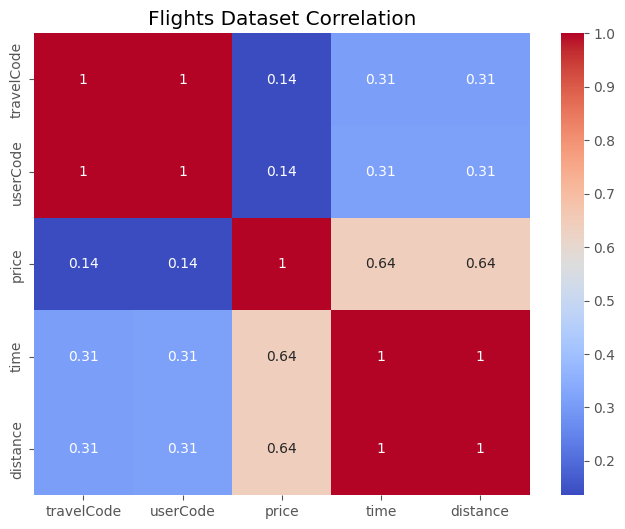

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    flights.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Flights Dataset Correlation")

plt.show()

###  Flights Dataset Correlation — Key Observations

* **Perfect Collinearity — `time` vs `distance` ($r = 1.00$):**
  * `time` and `distance` have a **perfect positive correlation of 1.00**, indicating that flight duration is directly proportional to (or calculated from) travel distance.
  * *Modeling Impact:* One of these two features should be dropped to prevent severe **multicollinearity** in linear regression models.

* **Duplicate Identifier Link — `travelCode` vs `userCode` ($r = 1.00$):**
  * `travelCode` and `userCode` exhibit a **1.00 correlation**, revealing a 1-to-1 mapping or redundant index coupling between these ID columns.

* **Primary Price Predictors — `price` vs `distance` & `time` ($r = 0.64$):**
  * Flight `price` has a moderate-to-strong positive correlation of **0.64** with both `distance` and `time`. Longer distances and flight times consistently drive higher ticket prices.

* **Weak ID Correlations ($r = 0.14$ – $0.31$):**
  * Numerical ID codes (`travelCode` and `userCode`) show weak correlations with `price` (**0.14**) and `distance`/`time` (**0.31**), as expected for categorical/identifier fields.


## Hotels Heatmap

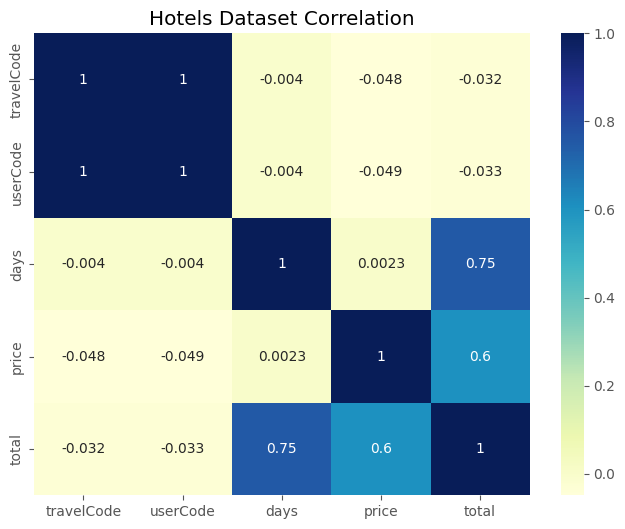

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    hotels.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Hotels Dataset Correlation")

plt.show()

###  Hotels Dataset Correlation — Key Observations

* **Primary Drivers of Total Booking Cost (`total`):**
  * **Stay Duration (`days` vs `total`):** Strongest positive correlation at **0.75**. Length of stay is the primary determinant of total hotel expenditure.
  * **Daily Nightly Rate (`price` vs `total`):** Strong positive correlation at **0.60**. Nightly room rate serves as the secondary key driver of total cost ($\text{Total} \approx \text{Days} \times \text{Price}$).

* **Independence of Stay Length & Nightly Rate (`days` vs `price` = 0.00):**
  * The correlation between `days` and `price` is virtually **0.00** (**0.0023**). This indicates that nightly hotel rates remain constant regardless of stay duration (no long-stay discounts are baked into the raw rates).

* **Identifier Redundancy (`travelCode` vs `userCode` = 1.00):**
  * `travelCode` and `userCode` exhibit a perfect **1.00 correlation**, confirming a 1-to-1 mapping between travel records and user identifiers.

* **Negligible ID Influence ($r = -0.05$ to $0.00$):**
  * ID columns show virtually zero linear correlation with numerical features (`days`, `price`, `total`), ranging from **-0.05 to 0.00**.


# Dataset Relationship Analysis

The three datasets are interconnected through common identifiers.

- `userCode` links Users, Flights, and Hotels datasets.
- `travelCode` links Flights and Hotels datasets.

Understanding these relationships is essential before building integrated machine learning pipelines.

In [44]:
print("Unique Users :", users["code"].nunique())

print("Users in Flights :", flights["userCode"].nunique())

print("Users in Hotels :", hotels["userCode"].nunique())

print("Travel Codes in Flights :", flights["travelCode"].nunique())

print("Travel Codes in Hotels :", hotels["travelCode"].nunique())

Unique Users : 1340
Users in Flights : 1335
Users in Hotels : 1310
Travel Codes in Flights : 135944
Travel Codes in Hotels : 40552


In [49]:
relationship = pd.DataFrame({
    "Category": [
        "Users Dataset",
        "Users in Flights",
        "Users in Hotels",
        "Travel Codes in Flights",
        "Travel Codes in Hotels"
    ],
    "Count": [
        users["code"].nunique(),
        flights["userCode"].nunique(),
        hotels["userCode"].nunique(),
        flights["travelCode"].nunique(),
        hotels["travelCode"].nunique()
    ]
})

relationship

,Category,Count
0,Users Dataset,1340
1,Users in Flights,1335
2,Users in Hotels,1310
3,Travel Codes in Flights,135944
4,Travel Codes in Hotels,40552


### Visulaize in Venn Diagram

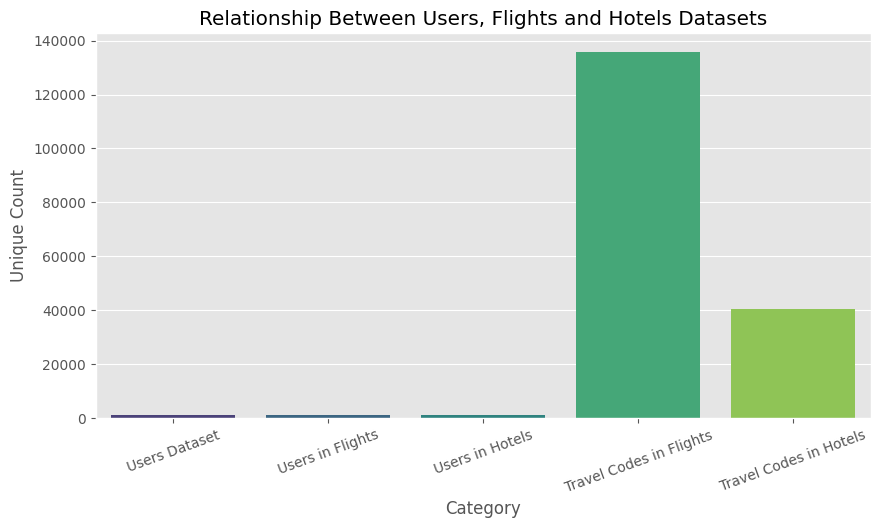

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=relationship,
    x="Category",
    y="Count",
    palette="viridis"
)

plt.title("Relationship Between Users, Flights and Hotels Datasets")

plt.xticks(rotation=20)

plt.ylabel("Unique Count")

plt.show()

###  Relationship Between Datasets — Observations

* **High User Coverage & Alignment:**
  * **Total Base Users (`Users Dataset`):** **1,340.00** unique users.
  * **Users in Flights:** **1,335.00** unique users (**~99.63%** coverage of the base user pool).
  * **Users in Hotels:** **1,310.00** unique users (**~97.76%** coverage of the base user pool).
  * *Insight:* Almost all registered users (**~97.76%–99.63%**) have associated flight and hotel booking activity.

* **Travel Volume Scale Disparity:**
  * **Travel Codes in Flights:** **135,944.00** unique flight bookings.
  * **Travel Codes in Hotels:** **40,552.00** unique hotel bookings.
  * *Insight:* Flight records outnumber hotel bookings by a ratio of **~3.35 : 1**. Only **~29.83%** of flight travel events include a corresponding hotel stay, indicating a high volume of single-day business trips or independent travel arrangements.


In [51]:
common_travel = len(
    set(flights["travelCode"]).intersection(
        set(hotels["travelCode"])
    )
)

print(f"Common Travel Codes : {common_travel}")

Common Travel Codes : 40552


### Observation

- A total of **40,552 common travel codes** were identified between the Flights and Hotels datasets.
- This confirms a strong relationship between flight bookings and hotel bookings.
- The `travelCode` attribute can be used as a reliable key for merging both datasets during feature engineering.

### Business Insight

The presence of a large number of common travel records enables the development of integrated travel analytics.

This relationship can be leveraged to:

- Build personalized hotel recommendation systems.
- Analyze complete travel journeys.
- Improve customer behavior analysis.
- Create richer machine learning features by combining flight and hotel information.

## Travel Code Relationship 

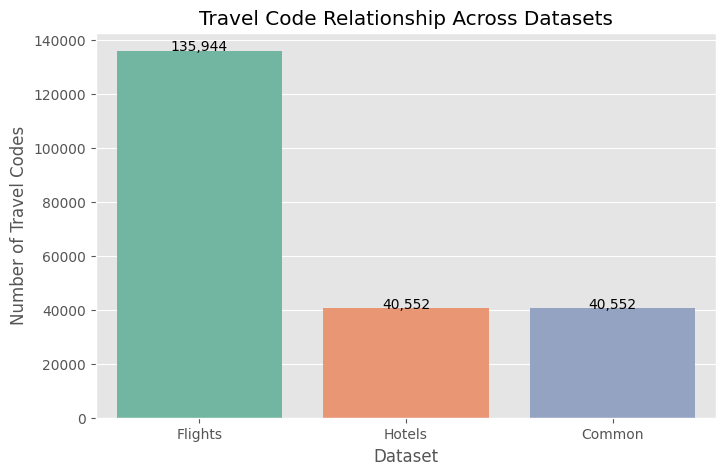

In [52]:
travel_relationship = pd.DataFrame({
    "Dataset": ["Flights", "Hotels", "Common"],
    "Travel Codes": [
        flights["travelCode"].nunique(),
        hotels["travelCode"].nunique(),
        common_travel
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=travel_relationship,
    x="Dataset",
    y="Travel Codes",
    palette="Set2"
)

plt.title("Travel Code Relationship Across Datasets")
plt.ylabel("Number of Travel Codes")

for index, value in enumerate(travel_relationship["Travel Codes"]):
    plt.text(index, value + 100, f"{value:,}", ha="center", fontsize=10)

plt.show()

### Key Observations

* **100.00% Hotel Match Rate (`Common = Hotels`):**
  * All **40,552.00** hotel travel codes (**100.00%**) have a matching record in the `Flights` dataset.
  * There are **0.00** orphan hotel records, confirming perfect relational integrity from Hotels to Flights.

* **Flight Accommodation Ratio:**
  * **Total Flights:** **135,944.00** travel codes.
  * **Flights with Hotel Stay (`Common`):** **40,552.00** travel codes (**29.83%**).
  * **Standalone Flights (No Hotel):** **95,392.00** travel codes (**70.17%**).

* **Database Merge Strategy:**
  * Performing an `INNER JOIN` on `travelCode` yields exactly **40,552.00** complete flight+hotel travel itineraries.
  * Performing a `LEFT JOIN` from `Flights` to `Hotels` retains all **135,944.00** flights while populating hotel attributes for the **29.83%** of journeys with accommodations.


#   Final Conclusion & Executive Summary

The Exploratory Data Analysis (EDA) of the **TravelOps AI** platform evaluated three core interconnected datasets: **Users**, **Flights**, and **Hotels** (linked via `userCode` and `travelCode`). 

No missing values or duplicate records were detected during initial data validation checks.

---

##  Summary of Quantitative Key Findings

### 1. User Demographics (`users` dataset)
* **Sample Size:** 1,340.00 total registered user profiles.
* **Age Profile:** Spans from **21.00 to 65.00 years** (44.00-year range) with a near-uniform distribution across working-age adults. The primary mode peaks at **33.00 years** (~107.00 users).
* **Gender Balance:** Equally split across **`male`** (33.73%), **`female`** (33.43%), and **`none` / Unspecified** (32.84%).
* **Corporate Market Share:** **`4You`** is the dominant employer representing **33.73%** (~452.00 users) of total corporate travel volume, followed by `Acme Factory` (19.48%), `Wonka Company` (17.76%), `Monsters CYA` (14.55%), and `Umbrella LTDA` (14.48%).

### 2. Flight Dynamics (`flights` dataset)
* **Price Distribution:** Flight prices range from **$300.00 to $1,750.00**, with a median of **$900.00** and an IQR of **$550.00** ($Q_1 = \$675.00, Q_3 = \$1,225.00$).
* **Price Drivers:** Flight distance (170.00–950.00 km) strongly influences ticket price (**$r = 0.64$**). High variance at fixed distances indicates secondary factors (e.g., airline, booking window, cabin class).
* **Multicollinearity Warning:** `time` and `distance` exhibit a **perfect linear correlation ($r = 1.00$)**, indicating `time` is derived directly from distance.

### 3. Hotel Booking Dynamics (`hotels` dataset)
* **Stay Duration:** Uniformly distributed across **1, 2, 3, and 4 days** (~10,150 to ~10,200 bookings per duration category).
* **Nightly Rate Multimodality:** Hotel prices show 5 distinct price tiers ($60–$75, $130–$145, $160–$175, $230–$280, and a $300–$315 peak spike), with a notable market gap between **$80.00 and $125.00**.
* **Total Booking Cost (`total`):** Median total cost is **$500.00** ($Q_1 = \$250.00, Q_3 = \$750.00$), ranging from **$60.00 to $1,250.00** with **0 statistical outliers**.
* **Cost Correlation Drivers:** Total cost is primarily driven by stay length `days` (**$r = 0.75$**) and nightly rate `price` (**$r = 0.60$**). `days` and `price` are independent (**$r = 0.00$**).

---

##  Critical Preprocessing & Modeling Directives

1. **Multicollinearity Reduction:** Drop `time` from the flight dataset prior to linear regression modeling due to its **1.00 correlation** with `distance`.
2. **Feature Engineering:**
   * Create **`price_per_km`** ($\frac{\text{Flight Price}}{\text{Distance}}$) to capture relative route cost efficiency.
   * Derive total travel cost by merging flight prices and hotel stay total costs.
3. **Data Transformations:** Apply a **Log Transformation (`np.log1p`)** on right-skewed numerical target variables (`flight_price` and `hotel_total_cost`) to normalize distribution tails.
4. **Categorical Encoding:** One-Hot Encode categorical variables (`gender`, `company`, `place`). Handle the 32.84% unstated `none` gender explicitly as an independent category.

---

